Visualisation des données

Ajout des bibliothèques et chargement du fichier csv

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cves_enriched_local.csv")
print("Nombre de lignes :", len(df))
print(df.head(5))

Nombre de lignes : 60807
  ID du bulletin (ANSSI)                          Titre du bulletin (ANSSI)  \
0    CERTFR-2024-ALE-009                         Vulnérabilité dans OpenSSH   
1    CERTFR-2024-ALE-007   Multiples vulnérabilités dans les produits Cisco   
2    CERTFR-2024-ALE-007   Multiples vulnérabilités dans les produits Cisco   
3    CERTFR-2023-ALE-005  Synthèse sur l'exploitation d'une vulnérabilit...   
4    CERTFR-2023-ALE-005  Synthèse sur l'exploitation d'une vulnérabilit...   

  Type de bulletin Date de publication Identifiant CVE Score CVSS  \
0           Alerte          2024-10-07   CVE-2024-6387        8.1   
1           Alerte          2024-07-01  CVE-2024-20353        8.6   
2           Alerte          2024-07-01  CVE-2024-20359          6   
3           Alerte          2023-09-11  CVE-2023-34362        9.8   
4           Alerte          2023-09-11  CVE-2023-35036        9.1   

  Base Severity Type CWE                                    Description CWE  \
0     

Nettoyage des données

In [5]:
df["Score CVSS"] = pd.to_numeric(df["Score CVSS"], errors='coerce')
df["Score EPSS"] = pd.to_numeric(df["Score EPSS"], errors='coerce')

Histogramme des scores CVSS

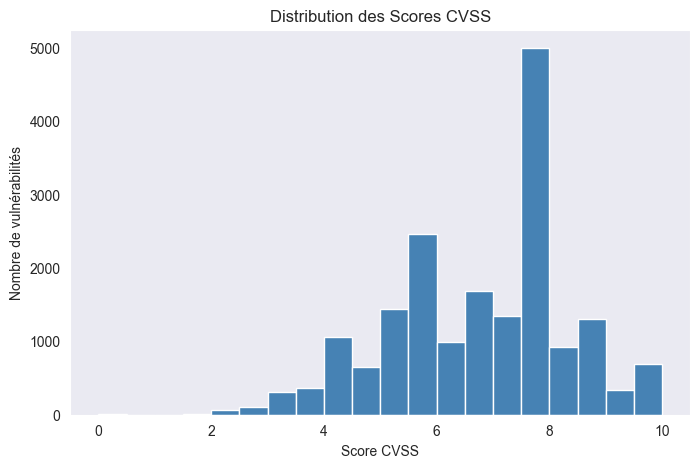

In [6]:
plt.figure(figsize=(8,5))
df["Score CVSS"].dropna().hist(bins=20, color='steelblue')
plt.title("Distribution des Scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.grid()
plt.show()

//interprétation

Diagramme circulaire des types de vulnérabilités (CWE)

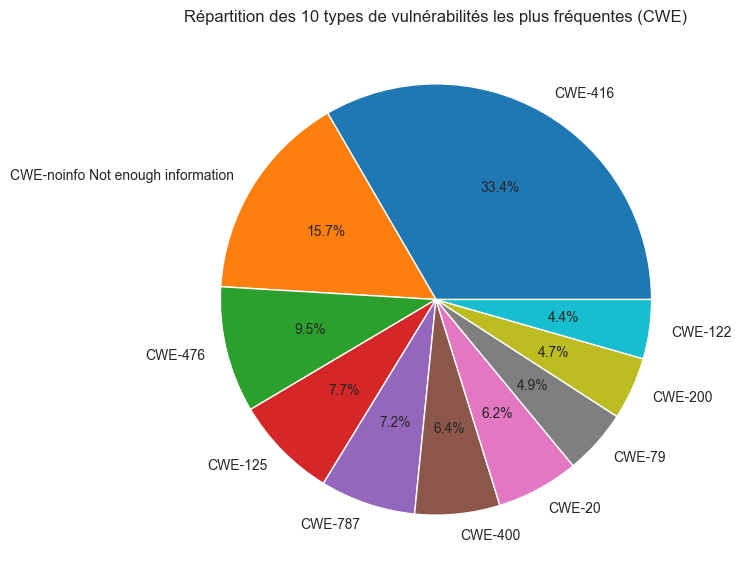

In [8]:
plt.figure(figsize=(7,7))
df_cwe = df[df["Type CWE"] != "Non disponible"] #on enlève les données "non disponible" car ça n'a pas de sens de les garder pour cette visualisation
df_cwe["Type CWE"].value_counts().head(10).plot.pie(autopct="%1.1f%%")
plt.title("Répartition des 10 types de vulnérabilités les plus fréquentes (CWE)")
plt.ylabel("")
plt.show()

// interprétation

Courbe des scores EPSS

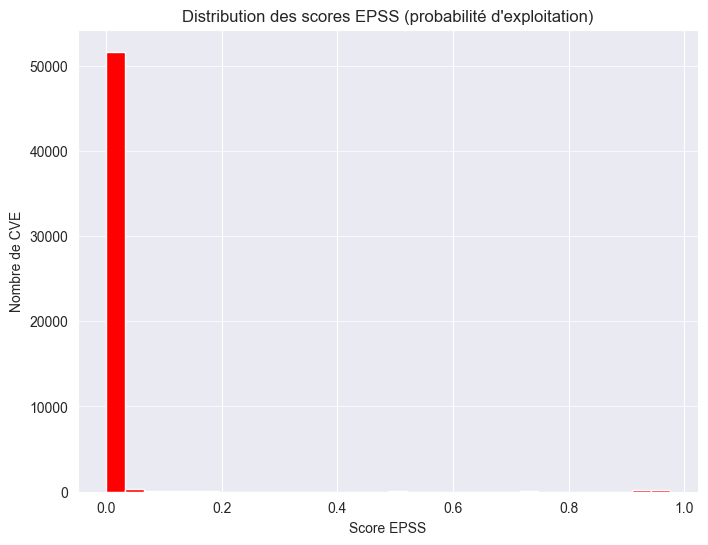

In [12]:
df_epss = df[df["Score EPSS"] != "Non disponible"].copy()
df_epss["Score EPSS"] = pd.to_numeric(df_epss["Score EPSS"])
plt.figure(figsize=(8,6))
plt.hist(df_epss["Score EPSS"], bins=30, color="red")
plt.title("Distribution des scores EPSS (probabilité d'exploitation)")
plt.xlabel("Score EPSS")
plt.ylabel("Nombre de CVE")
plt.grid(axis='y', alpha=0.75)
plt.show()

//interprétation

Classement des produits ou éditeurs les plus affectés

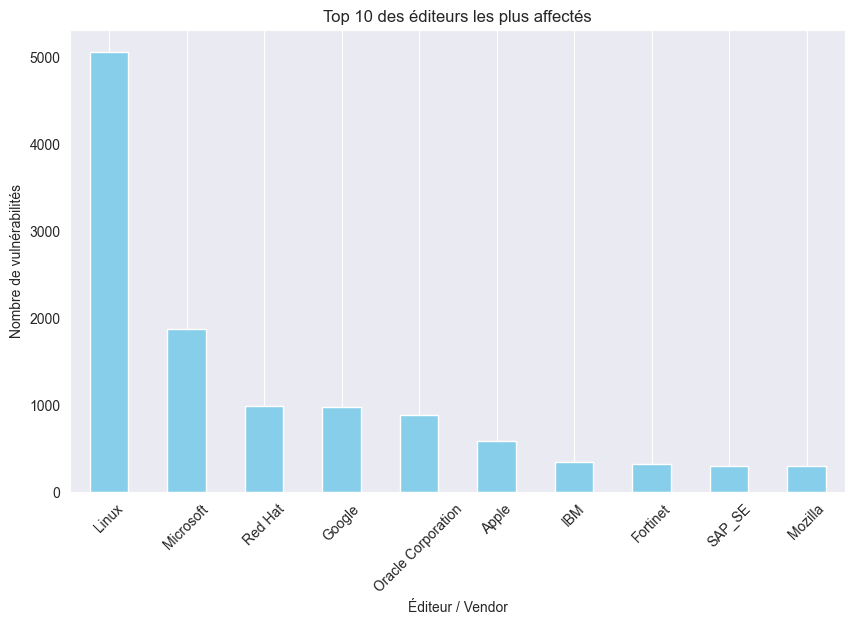

In [20]:
df_vendor = df[df["Éditeur/Vendor"] != "Non disponible"]
top_vendors = df_vendor["Éditeur/Vendor"].value_counts().head(10)
plt.figure(figsize=(10,6))
top_vendors.plot(kind="bar", color="skyblue")
plt.title("Top 10 des éditeurs les plus affectés")
plt.xlabel("Éditeur / Vendor")
plt.ylabel("Nombre de vulnérabilités")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

//interprétation

Heatmap des corrélations entre CVSS et EPSS

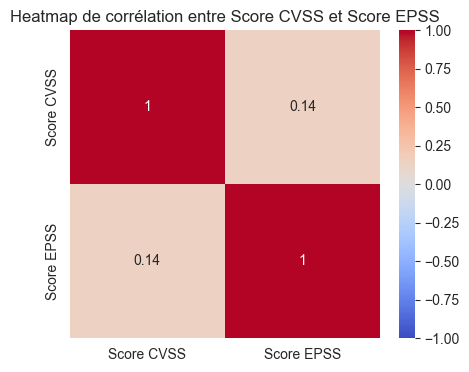

In [19]:
correlation = df[["Score CVSS", "Score EPSS"]].corr()
plt.figure(figsize=(5,4))
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap de corrélation entre Score CVSS et Score EPSS")
plt.show()

//interprétation

Nuage de points entre Score CVSS et Score EPSS

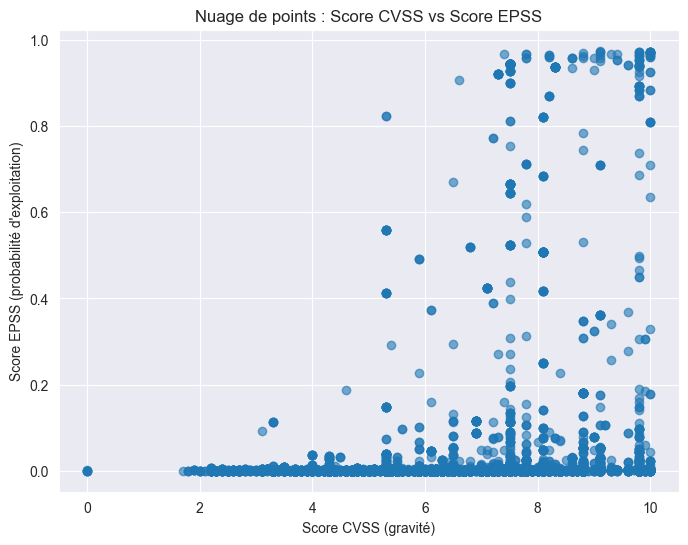

In [18]:
df_scatter = df.dropna(subset=["Score CVSS", "Score EPSS"])
plt.figure(figsize=(8,6))
plt.scatter(df_scatter["Score CVSS"], df_scatter["Score EPSS"], alpha=0.6)
plt.title("Nuage de points : Score CVSS vs Score EPSS")
plt.xlabel("Score CVSS (gravité)")
plt.ylabel("Score EPSS (probabilité d'exploitation)")
plt.grid(True)
plt.show()

//interprétation

Courbe cumulative des vulnérabilités en fonction du temps

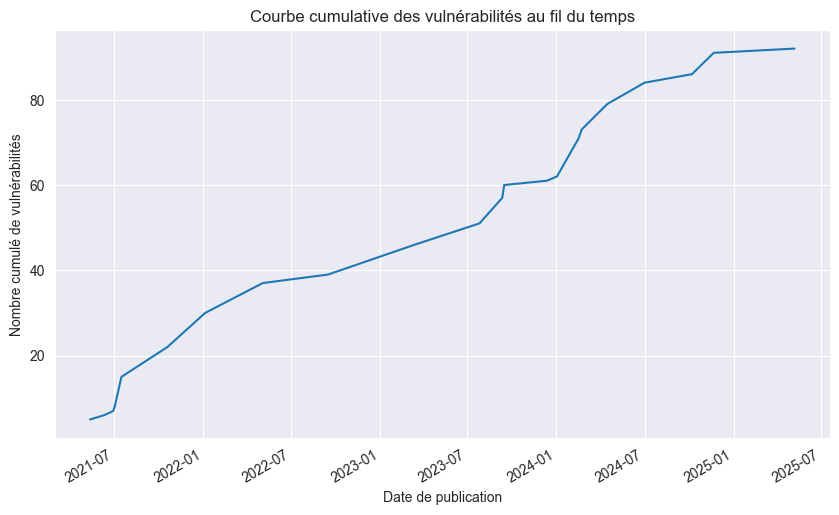

In [21]:
df["Date de publication"] = pd.to_datetime(df["Date de publication"], errors='coerce')

df_date = df.dropna(subset=["Date de publication"])#on retire les données manquantes
df_daily = df_date.groupby("Date de publication").size().sort_index() #on compte le nombre de CVE par date
df_cumulative = df_daily.cumsum()

plt.figure(figsize=(10,6))
df_cumulative.plot()
plt.title("Courbe cumulative des vulnérabilités au fil du temps")
plt.xlabel("Date de publication")
plt.ylabel("Nombre cumulé de vulnérabilités")
plt.grid(True)
plt.show()

//interprétation

Boxplot des scores CVSS par éditeur

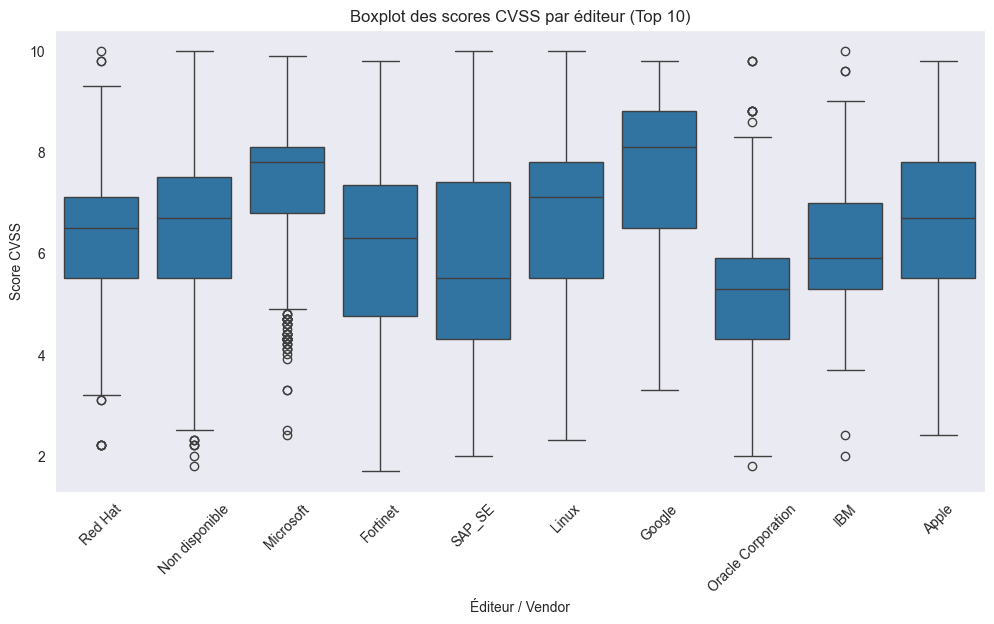

In [22]:
df_box = df.dropna(subset=["Score CVSS"]) #on prend que les lignes avec un score cvss disponible
top_vendors = df_box["Éditeur/Vendor"].value_counts().head(10).index

df_top_vendors = df_box[df_box["Éditeur/Vendor"].isin(top_vendors)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top_vendors, x="Éditeur/Vendor", y="Score CVSS")
plt.title("Boxplot des scores CVSS par éditeur (Top 10)")
plt.xlabel("Éditeur / Vendor")
plt.ylabel("Score CVSS")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


// interprétation

Evolution temporelle du nombre de vulnérabilités détectées

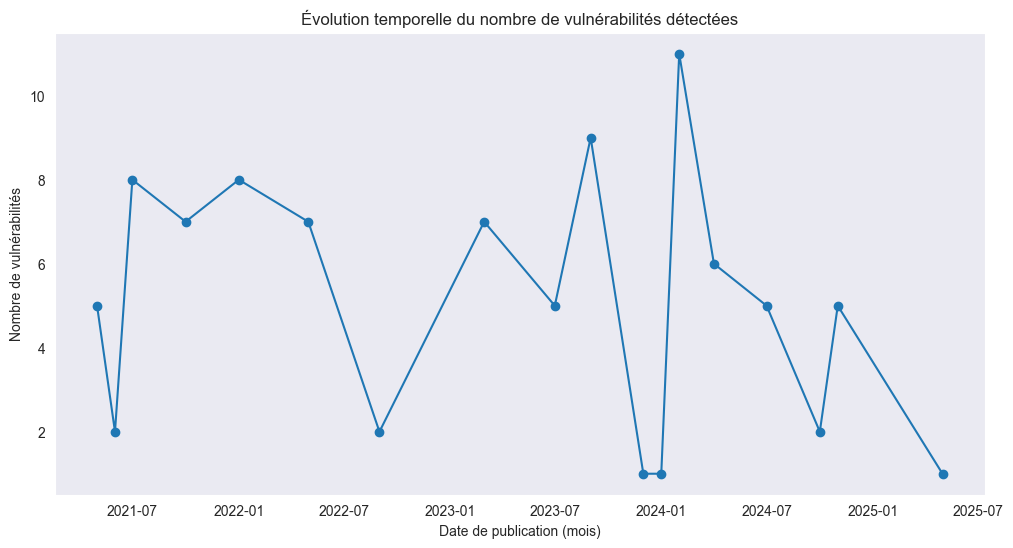

In [24]:
df["Date de publication"] = pd.to_datetime(df["Date de publication"], errors="coerce")

df_valid = df.dropna(subset=["Date de publication"]) #on enlève les dates invalides
df_valid = df_valid.copy()

df_valid["mois"] = df_valid["Date de publication"].dt.to_period("M") #regroupement par mois

df_counts = df_valid.groupby("mois").size().reset_index(name="nombre_vulnerabilites") #compte le nombre de vulnérabilité par mois
df_counts["mois"] = df_counts["mois"].dt.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(df_counts["mois"], df_counts["nombre_vulnerabilites"], marker='o', linestyle='-')
plt.title("Évolution temporelle du nombre de vulnérabilités détectées")
plt.xlabel("Date de publication (mois)")
plt.ylabel("Nombre de vulnérabilités")
plt.grid()
plt.show()

// interprétation

Versions les plus fréquemment touchées des produits concernés

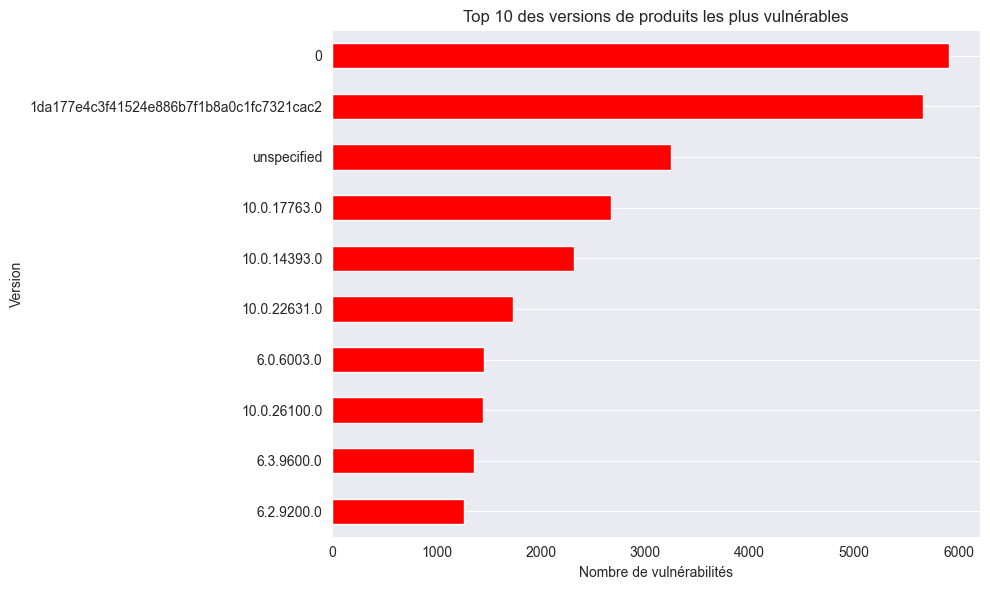

In [26]:
df_versions = df[df["Versions affectées"].notna() & (df["Versions affectées"] != "")]
df_versions = df_versions.copy()

df_versions["Versions affectées"] = df_versions["Versions affectées"].str.split(", ")
df_versions_exploded = df_versions.explode("Versions affectées")

df_versions_exploded = df_versions_exploded[
    (df_versions_exploded["Versions affectées"] != "Non disponible") &
    (df_versions_exploded["Versions affectées"] != "")
]

top_versions = df_versions_exploded["Versions affectées"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_versions.plot(kind='barh', color='red')
plt.xlabel("Nombre de vulnérabilités")
plt.ylabel("Version")
plt.title("Top 10 des versions de produits les plus vulnérables")
plt.gca().invert_yaxis()  #pour avoir la version la plus touchée en haut
plt.grid(axis='x')
plt.tight_layout()
plt.show()

//interprétation

Analyse du nombre de vulnérabilités par éditeur et distinguer les types de bulletins (avis ou alertes).

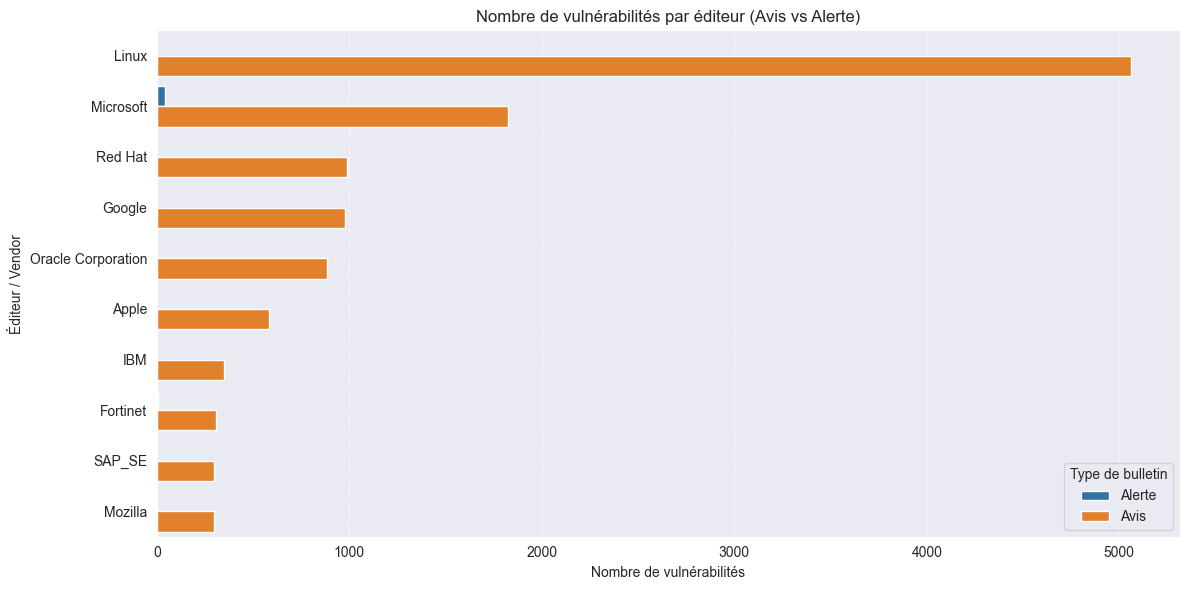

In [27]:
df_valid = df[df["Éditeur/Vendor"].notna() & (df["Éditeur/Vendor"] != "Non disponible")]

top_vendors = df_valid["Éditeur/Vendor"].value_counts().head(10).index

df_top_vendors = df_valid[df_valid["Éditeur/Vendor"].isin(top_vendors)]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_top_vendors,
    y="Éditeur/Vendor",
    hue="Type de bulletin",
    order=top_vendors
)
plt.title("Nombre de vulnérabilités par éditeur (Avis vs Alerte)")
plt.xlabel("Nombre de vulnérabilités")
plt.ylabel("Éditeur / Vendor")
plt.legend(title="Type de bulletin")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

//interprétation

Dispersion des scores CVSS pour les éditeurs les plus affectés

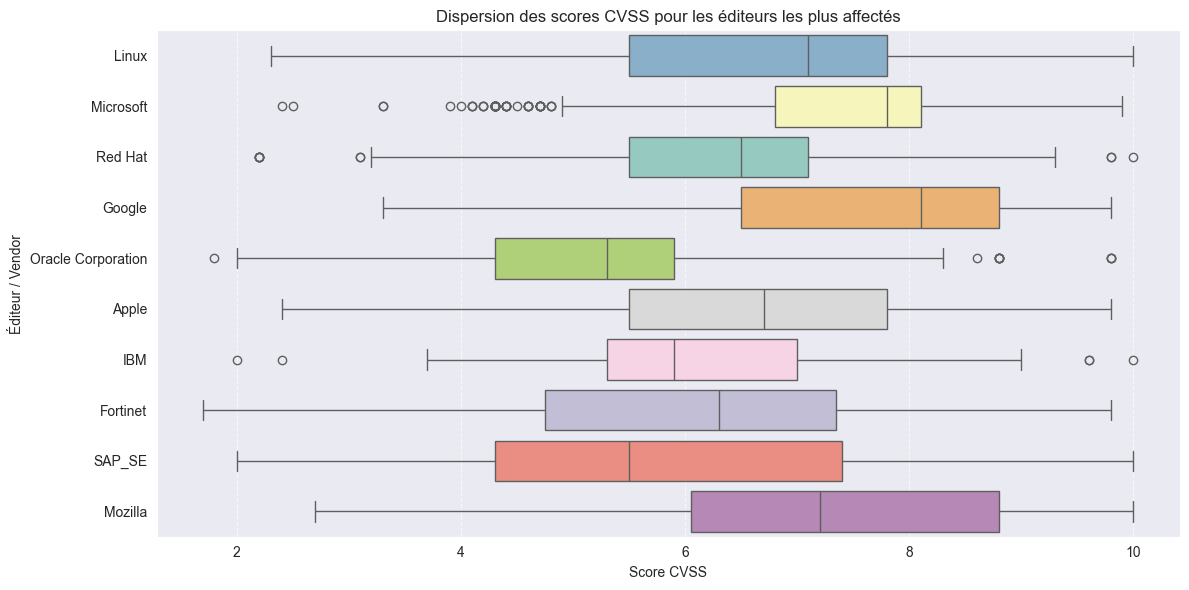

In [29]:
df_valid = df[df["Éditeur/Vendor"].notna() & (df["Éditeur/Vendor"] != "Non disponible")]
top_vendors = df_valid["Éditeur/Vendor"].value_counts().head(10).index
df_top_vendors = df_valid[df_valid["Éditeur/Vendor"].isin(top_vendors)]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_top_vendors,
    y="Éditeur/Vendor",
    x="Score CVSS",
    order=top_vendors,
    hue="Éditeur/Vendor",   # <-- Ajout recommandé
    palette="Set3",
    legend=False
)
plt.title("Dispersion des scores CVSS pour les éditeurs les plus affectés")
plt.xlabel("Score CVSS")
plt.ylabel("Éditeur / Vendor")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

//interprétation

Chargement du fichier .csv

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df = pd.read_csv("cves_enriched_local.csv")
print("Nombre de lignes :", len(df))
df.head()